In [1]:
import matplotlib as mpl
import matplotlib.pyplot as plt
%matplotlib inline
import numpy as np
import sklearn
import pandas as pd
import os
import sys
import time
from tqdm.auto import tqdm
import torch
import torch.nn as nn
import torch.nn.functional as F
from pathlib import Path

print(sys.version_info)

device = torch.device("cuda:0") if torch.cuda.is_available() else torch.device("cpu")
print(device)

DATA_DIR = Path("D:/cifar-10")

train_lables_file = DATA_DIR / "trainLabels.csv"
test_csv_file = DATA_DIR / "sampleSubmission.csv"
train_folder = DATA_DIR / "train/train"
test_folder = DATA_DIR / "test/test"

class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

import pandas as pd

def load_image_paths_and_labels(labels_csv_path, images_folder):
    df = pd.read_csv(labels_csv_path)
    items = []
    for idx, row in df.iterrows():
        img_name = row['id']
        label = row['label']
        img_path = images_folder / f"{img_name}.png"
        if not img_path.exists():
            img_path = images_folder / f"{img_name}.jpg"
        items.append( (str(img_path), label) )
    return items

train_items = load_image_paths_and_labels(train_lables_file, train_folder)

print(train_items[:5])

sys.version_info(major=3, minor=13, micro=5, releaselevel='final', serial=0)
cuda:0
[('D:\\cifar-10\\train\\train\\1.png', 'frog'), ('D:\\cifar-10\\train\\train\\2.png', 'truck'), ('D:\\cifar-10\\train\\train\\3.png', 'truck'), ('D:\\cifar-10\\train\\train\\4.png', 'deer'), ('D:\\cifar-10\\train\\train\\5.png', 'automobile')]


In [2]:
train_items_ = train_items[:45000]
valid_items = train_items[45000:]

train_df = pd.DataFrame(train_items_, columns=['img_path', 'label'])
valid_df = pd.DataFrame(valid_items, columns=['img_path', 'label'])

In [3]:
from PIL import Image
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

class Cifar10Dataset(Dataset):
    df_map = {
        "train": train_df,
        "eval": valid_df,
    }
    label_to_idx = {label: idx for idx, label in enumerate(class_names)}
    idx_to_label = {idx: label for idx, label in enumerate(class_names)}
    def __init__(self, mode, transform=None):
        self.df = self.df_map.get(mode, None)
        if self.df is None:
            raise ValueError("mode should be one of train, val, test, but got {}".format(mode))
        self.transform = transform

    def __getitem__(self, index):
        img_path, label = self.df.iloc[index]
        img = Image.open(img_path).convert('RGB')
        img = self.transform(img)
        
        label = self.label_to_idx[label]
        return img, label

    def __len__(self):
        return self.df.shape[0]

IMAGE_SIZE = 32
mean, std = [0.4914, 0.4822, 0.4465], [0.247, 0.243, 0.261]

transforms_train = transforms.Compose([
        transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
        transforms.RandomRotation(40),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize(mean, std)
    ])

transforms_eval = transforms.Compose([
        transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize(mean, std)
    ])

train_ds = Cifar10Dataset("train", transforms_train)
eval_ds = Cifar10Dataset("eval", transforms_eval)

In [4]:
batch_size = 32

train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(eval_ds, batch_size=batch_size, shuffle=False)

for batch_images, batch_labels in train_loader:
    print(batch_images.shape)
    print(batch_labels.shape)
    break

torch.Size([32, 3, 32, 32])
torch.Size([32])


In [5]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class ResidualBlock(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1, downsample=None):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU(inplace=True)
        
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)
        self.downsample = downsample
        
    def forward(self, x):
        identity = x
        
        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)
        
        out = self.conv2(out)
        out = self.bn2(out)
        
        if self.downsample is not None:
            identity = self.downsample(x)
        
        out += identity
        out = self.relu(out)
        return out
        
class ResNet(nn.Module):    # 定义ResNet18模型
    def __init__(self, num_classes=10):
        super().__init__()
        self.in_channels = 64
        
        self.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(64)
        self.relu = nn.ReLU(inplace=True)
        # self.maxpool = nn.MaxPool2d(kernel_size=3, stride=2, padding=1)
        
        self.layer1 = self._make_layer(64, 2, stride=1)
        self.layer2 = self._make_layer(128, 2, stride=2)
        self.layer3 = self._make_layer(256, 2, stride=2)
        self.layer4 = self._make_layer(512, 2, stride=2)
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(512, num_classes)
    
    def _make_layer(self, out_channels, blocks, stride):
        downsample = None
        if stride != 1 or self.in_channels != out_channels:
            downsample = nn.Sequential(
                nn.Conv2d(self.in_channels, out_channels, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(out_channels)
            )
        
        layers = []
        layers.append(ResidualBlock(self.in_channels, out_channels, stride, downsample))
        self.in_channels = out_channels
        for _ in range(1, blocks):
            layers.append(ResidualBlock(out_channels, out_channels))
        
        return nn.Sequential(*layers)
    def forward(self, x):
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)
        # x = self.maxpool(x)
        
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)
        
        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.fc(x)
        
        return x
        
model = ResNet(num_classes=10)

In [6]:
import torch
import torch.nn as nn
import torch.optim as optim

dummy_input = torch.randn(32, 3, 32, 32)
output = model(dummy_input)
print(output.shape)

total_params = 0
for name, param in model.named_parameters():
    if param.requires_grad:
        num_params = param.numel()
        total_params += param.numel()
        print(f"{name}: {num_params}")
print(f"Total number of parameters: {total_params}")

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

torch.Size([32, 10])
conv1.weight: 1728
bn1.weight: 64
bn1.bias: 64
layer1.0.conv1.weight: 36864
layer1.0.bn1.weight: 64
layer1.0.bn1.bias: 64
layer1.0.conv2.weight: 36864
layer1.0.bn2.weight: 64
layer1.0.bn2.bias: 64
layer1.1.conv1.weight: 36864
layer1.1.bn1.weight: 64
layer1.1.bn1.bias: 64
layer1.1.conv2.weight: 36864
layer1.1.bn2.weight: 64
layer1.1.bn2.bias: 64
layer2.0.conv1.weight: 73728
layer2.0.bn1.weight: 128
layer2.0.bn1.bias: 128
layer2.0.conv2.weight: 147456
layer2.0.bn2.weight: 128
layer2.0.bn2.bias: 128
layer2.0.downsample.0.weight: 8192
layer2.0.downsample.1.weight: 128
layer2.0.downsample.1.bias: 128
layer2.1.conv1.weight: 147456
layer2.1.bn1.weight: 128
layer2.1.bn1.bias: 128
layer2.1.conv2.weight: 147456
layer2.1.bn2.weight: 128
layer2.1.bn2.bias: 128
layer3.0.conv1.weight: 294912
layer3.0.bn1.weight: 256
layer3.0.bn1.bias: 256
layer3.0.conv2.weight: 589824
layer3.0.bn2.weight: 256
layer3.0.bn2.bias: 256
layer3.0.downsample.0.weight: 32768
layer3.0.downsample.1.weight

In [ ]:
import res_trainer as mt

early_stopping = mt.EarlyStopping(patience=5, min_delta=0.001,mode="min")

trainer = mt.Trainer(
    model=model,
    train_loader=train_loader,
    val_loader=test_loader,
    criterion=criterion,
    optimizer=optimizer,
    device=device,
    # early_stopping=early_stopping,
    eval_step=100
)

num_epochs = 20
trainer.train(num_epochs)

[Step 100] Val Loss: 1.8822 Val Acc: 0.2982
[Step 200] Val Loss: 1.9557 Val Acc: 0.2638
[Step 300] Val Loss: 1.9177 Val Acc: 0.2584
[Step 400] Val Loss: 1.7950 Val Acc: 0.3044
[Step 500] Val Loss: 1.6926 Val Acc: 0.3626
[Step 600] Val Loss: 1.7183 Val Acc: 0.3580
[Step 700] Val Loss: 1.6828 Val Acc: 0.3822
[Step 800] Val Loss: 1.6393 Val Acc: 0.4010
[Step 900] Val Loss: 1.6915 Val Acc: 0.3840
[Step 1000] Val Loss: 1.5122 Val Acc: 0.4294
[Step 1100] Val Loss: 1.5314 Val Acc: 0.4232
[Step 1200] Val Loss: 1.5928 Val Acc: 0.4070
[Step 1300] Val Loss: 1.5055 Val Acc: 0.4480
[Step 1400] Val Loss: 1.4397 Val Acc: 0.4584
Epoch [1/20]  Train Loss: 1.7556  Train Acc: 0.3502
[Step 1500] Val Loss: 1.5725 Val Acc: 0.4068
[Step 1600] Val Loss: 1.5623 Val Acc: 0.4112
[Step 1700] Val Loss: 1.6028 Val Acc: 0.4102
[Step 1800] Val Loss: 1.4051 Val Acc: 0.4702
[Step 1900] Val Loss: 1.3988 Val Acc: 0.4790
[Step 2000] Val Loss: 1.3810 Val Acc: 0.4790
[Step 2100] Val Loss: 1.3557 Val Acc: 0.4934
[Step 2200] 

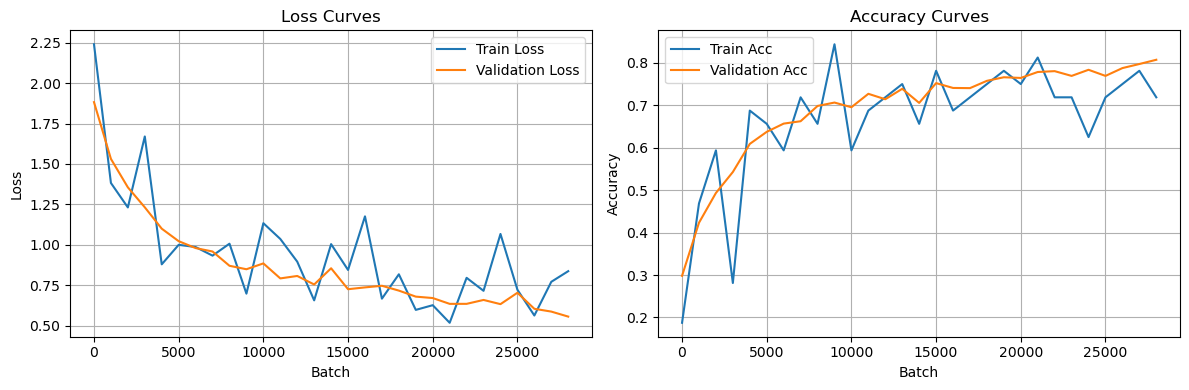

In [8]:
trainer.plot_curves()